In [1]:
# Install the pinned direct dependencies only in Google Colab.
try:
    import google.colab  # type: ignore[import-not-found]
except ImportError:
    pass
else:
    %pip install -q "jax==0.11.2" "jaxlib==0.11.2" "diffrax==0.7.2" "equinox==0.13.8" "optax==0.2.8" "numpy==2.5.3" "matplotlib==3.11.2"


In [2]:
import time

import diffrax
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

jax.config.update("jax_enable_x64", False)

In [3]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Neural ODEs


The previous notebooks identified dynamical systems by selecting a library of candidate terms and fitting sparse coefficients. A neural ordinary differential equation instead represents the vector field by a neural network $\mathbf{f}_{\boldsymbol{\theta}}:\mathbb{R}^d\to\mathbb{R}^d$. Its state $\mathbf{x}_{\boldsymbol{\theta}}(t;\mathbf{x}_0)$ solves

$$
\frac{d\mathbf{x}_{\boldsymbol{\theta}}}{dt}(t)=\mathbf{f}_{\boldsymbol{\theta}}\!\left(\mathbf{x}_{\boldsymbol{\theta}}(t)\right),
\qquad
\mathbf{x}_{\boldsymbol{\theta}}(0)=\mathbf{x}_0,
$$

where $\boldsymbol{\theta}$ collects the network weights and biases. The numerical ODE solution is differentiated with respect to these parameters during training {cite:p}`chen2018neuralode,kidger2021on`. This flexible representation usually sacrifices the term-by-term interpretation supplied by SINDy.

The example fits a neural ODE to synthetic noisy trajectories of a nonlinear oscillator, evaluates its trajectories and vector field against the known generator, and tests one initial condition excluded from training.



## The inverse problem

We observe noisy time series from a hidden dynamical system and seek the vector field that generated them. The synthetic generator is the two-dimensional Van der Pol oscillator with $\mu=1.5$:

$$
\dot x_1 = x_2,
$$

$$
\dot x_2 = \mu (1 - x_1^2)x_2 - x_1.
$$

For six specified initial states, the generator is integrated at $t_j=0.1j$ for $j=0,\ldots,60$. The observations satisfy

$$
\mathbf{y}^{(i)}_0=\mathbf{x}^{(i)}_0,
\qquad
\mathbf{y}^{(i)}_j
=\mathbf{x}^{(i)}(t_j)+\boldsymbol{\varepsilon}^{(i)}_j,
\quad j=1,\ldots,60,
\qquad
\boldsymbol{\varepsilon}^{(i)}_j
\overset{\mathrm{iid}}{\sim}
\mathcal{N}(\mathbf{0},0.03^2\mathbf{I}_2).
$$

The initial states are treated as known exactly, and the observation-noise seed is 1234. Optimization receives these initial states and the noisy samples; the exact vector field and clean trajectories are retained only for diagnostics.

Several trajectories constrain the vector field over more of state space than one orbit can cover. They do not, by themselves, establish global identifiability.


In [4]:
mu = 1.5
ts = jnp.linspace(0.0, 6.0, 61, dtype=jnp.float32)

def true_rhs(t, y, args):
    x1, x2 = y
    return jnp.array([x2, mu * (1.0 - x1**2) * x2 - x1], dtype=jnp.float32)

solver = diffrax.Tsit5()
stepsize_controller = diffrax.PIDController(rtol=1e-5, atol=1e-6)

def solve_trajectory(term, y0, ts):
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=0.1,
        y0=y0,
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=stepsize_controller,
        max_steps=4096,
    )
    return sol.ys

train_y0 = jnp.array(
    [
        [-1.5, 0.0],
        [-0.5, 1.0],
        [0.75, -1.0],
        [1.5, 0.5],
        [0.0, -1.5],
        [1.0, 1.0],
    ],
    dtype=jnp.float32,
)

true_term = diffrax.ODETerm(true_rhs)
true_trajectories = jax.vmap(lambda y0: solve_trajectory(true_term, y0, ts))(train_y0)
data_seed = 1234
_, noise_key = jax.random.split(jax.random.PRNGKey(data_seed))
noise_std = 0.03
observed_trajectories = true_trajectories + noise_std * jax.random.normal(
    noise_key, true_trajectories.shape
)
observed_trajectories = observed_trajectories.at[:, 0, :].set(train_y0)
realized_noise_mse = float(jnp.mean((observed_trajectories - true_trajectories) ** 2))

assert true_trajectories.shape == (6, 61, 2)

## Visualizing the observations

The clean trajectories are shown because the data are synthetic and the generator is available for verification. Training uses only the noisy samples and exact initial states.


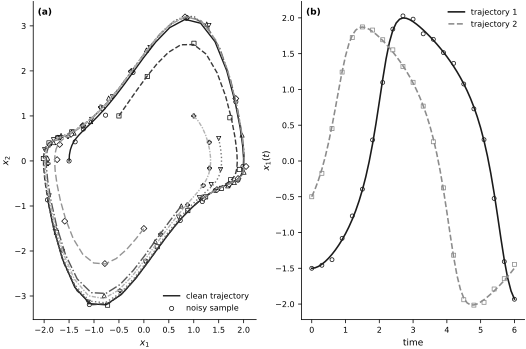

In [5]:
trajectory_grays = np.linspace(0.10, 0.70, train_y0.shape[0])
trajectory_styles = ["-", "--", "-.", ":", (0, (5, 2)), (0, (3, 1, 1, 1))]
trajectory_markers = ["o", "s", "^", "v", "D", "P"]

fig, axes = new_figure("full_standard", ncols=2)
for idx, (gray, linestyle, marker) in enumerate(
    zip(trajectory_grays, trajectory_styles, trajectory_markers)
):
    axes[0].plot(
        true_trajectories[idx, :, 0],
        true_trajectories[idx, :, 1],
        color=str(gray),
        linestyle=linestyle,
        linewidth=1.4,
        label="clean trajectory" if idx == 0 else None,
    )
    axes[0].scatter(
        observed_trajectories[idx, ::4, 0],
        observed_trajectories[idx, ::4, 1],
        marker=marker,
        s=18,
        facecolors="white",
        edgecolors="black",
        linewidths=0.7,
        label="noisy sample" if idx == 0 else None,
    )
axes[0].set(xlabel=r"$x_1$", ylabel=r"$x_2$")
axes[0].legend(loc="best")

for idx, (gray, linestyle, marker) in enumerate(
    zip((0.10, 0.55), ("-", "--"), ("o", "s"))
):
    axes[1].plot(
        ts,
        true_trajectories[idx, :, 0],
        color=str(gray),
        linestyle=linestyle,
        linewidth=1.6,
        label=f"trajectory {idx + 1}",
    )
    axes[1].scatter(
        ts[::3],
        observed_trajectories[idx, ::3, 0],
        marker=marker,
        s=16,
        facecolors="white",
        edgecolors=str(gray),
        linewidths=0.8,
    )
axes[1].set(xlabel="time", ylabel=r"$x_1(t)$")
axes[1].legend(loc="best")
label_panels(axes)
finalize_axes(axes)
plt.show()

## Neural ODE architecture

The vector field $\mathbf{f}_{\boldsymbol{\theta}}$ is a fully connected network from $\mathbb{R}^2$ to $\mathbb{R}^2$ with two hidden layers, 64 units per layer, and hyperbolic-tangent activations. The parameter-initialization seed is 1234 and is controlled independently of the observation-noise seed. A differentiable time integrator converts this local velocity model into complete trajectories.

The implementation uses the Diffrax Tsitouras 5/4 Runge--Kutta solver for both the synthetic generator and the learned neural ODE. Relative and absolute solver tolerances are $10^{-5}$ and $10^{-6}$, respectively. These numerical choices are part of the demonstrated model and can affect both the loss and its gradient. Because the hidden activations are bounded and the output layer is affine, this particular network defines a bounded vector field. The Van der Pol field is unbounded, so only recovery on a bounded region is representable.


In [6]:
class NeuralVectorField(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, key, width_size=64, depth=2):
        self.mlp = eqx.nn.MLP(
            in_size=2,
            out_size=2,
            width_size=width_size,
            depth=depth,
            activation=jax.nn.tanh,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.mlp(y)

model_seed = 1234
model_parent_key, _ = jax.random.split(jax.random.PRNGKey(model_seed))
_, model_key = jax.random.split(model_parent_key)
model = NeuralVectorField(model_key)
num_parameters = sum(
    leaf.size for leaf in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array))
)
print(f"Trainable parameters: {num_parameters:,}")

def solve_neural_ode(model, y0, ts):
    term = diffrax.ODETerm(model)
    return solve_trajectory(term, y0, ts)

Trainable parameters: 4,482


## Training objective

Let $M=6$ be the number of trajectories, $N+1=61$ the number of times, and $d=2$ the state dimension. The predicted state from initial condition $\mathbf{x}^{(i)}_0$ is $\widehat{\mathbf{x}}^{(i)}_j(\boldsymbol{\theta})=\mathbf{x}_{\boldsymbol{\theta}}(t_j;\mathbf{x}^{(i)}_0)$. We minimize

$$
\mathcal{L}(\boldsymbol{\theta})
=\frac{1}{M(N+1)d}
\sum_{i=1}^{M}\sum_{j=0}^{N}
\left\|
\widehat{\mathbf{x}}^{(i)}_j(\boldsymbol{\theta})
-\mathbf{y}^{(i)}_j
\right\|_2^2.
$$

The calculation uses 3,000 full-batch Adam updates with learning rate $2\times10^{-3}$ {cite:p}`kingma2015adam`. The reported wall time includes the first just-in-time compilation and identifies the JAX backend and device; it is a reproducibility diagnostic rather than an implementation-independent cost.

The neural-network parameters determine the unknown vector field, so trajectory matching is a finite-dimensional parameterization of a function-valued inverse problem.


In [7]:
def trajectory_mse(model, y0s, observed_ys):
    predicted = jax.vmap(lambda y0: solve_neural_ode(model, y0, ts))(y0s)
    return jnp.mean((predicted - observed_ys) ** 2)

loss_fn = eqx.filter_value_and_grad(trajectory_mse)

optimizer = optax.adam(2e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
num_steps = 3000

@eqx.filter_jit
def train_step(model, opt_state, y0s, observed_ys):
    loss, grads = loss_fn(model, y0s, observed_ys)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

loss_history = []
start = time.time()
for step in range(1, num_steps + 1):
    model, opt_state, loss = train_step(model, opt_state, train_y0, observed_trajectories)
    loss_history.append(float(loss))

elapsed_seconds = time.time() - start
final_loss = float(trajectory_mse(model, train_y0, observed_trajectories))
loss_history.append(final_loss)
device = jax.devices()[0]
print(
    f"{num_steps:,} updates | first loss {loss_history[0]:.6f} | "
    f"final loss {final_loss:.6f} | realized noise MSE {realized_noise_mse:.6f} | "
    f"ratio {final_loss / realized_noise_mse:.1f}\n"
    f"compile-inclusive time: {elapsed_seconds:.2f} seconds | "
    f"backend: {device.platform} | device: {device.device_kind}"
)

3,000 updates | first loss 3.385007 | final loss 0.004628 | realized noise MSE 0.000850 | ratio 5.4
compile-inclusive time: 19.11 seconds | backend: cpu | device: cpu


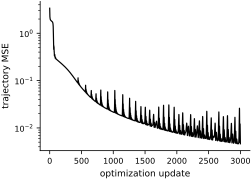

In [8]:
fig, axis = new_figure("half_standard")
axis.semilogy(
    np.arange(num_steps + 1),
    loss_history,
    color="black",
    linewidth=1.2,
)
axis.set(xlabel="optimization update", ylabel="trajectory MSE")
finalize_axes(axis)
plt.show()

## Training-set fit and vector-field recovery

A low trajectory error is necessary but not sufficient. We report the vector-field error at the clean training-trajectory states and over a larger display rectangle. The second region contains many states unsupported by the observations, so its error probes extrapolation of the vector field rather than training fit.


Training-trajectory relative error: 0.0449
Visited-state vector-field relative error: 0.1494
Rectangle-wide vector-field relative error: 0.6906


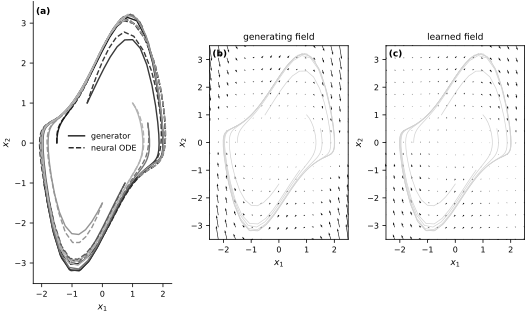

In [9]:
predicted_trajectories = jax.vmap(lambda y0: solve_neural_ode(model, y0, ts))(train_y0)
train_rel_error = jnp.linalg.norm(
    predicted_trajectories - true_trajectories
) / jnp.linalg.norm(true_trajectories)

grid_x1 = jnp.linspace(-2.5, 2.5, 17)
grid_x2 = jnp.linspace(-3.5, 3.5, 17)
mesh_x1, mesh_x2 = jnp.meshgrid(grid_x1, grid_x2)
grid_points = jnp.stack([mesh_x1.ravel(), mesh_x2.ravel()], axis=1)
true_vectors = jax.vmap(lambda y: true_rhs(0.0, y, None))(grid_points)
learned_vectors = jax.vmap(lambda y: model(0.0, y, None))(grid_points)
rectangle_field_rel_error = jnp.linalg.norm(
    learned_vectors - true_vectors
) / jnp.linalg.norm(true_vectors)

visited_points = true_trajectories.reshape((-1, 2))
visited_true_vectors = jax.vmap(lambda y: true_rhs(0.0, y, None))(visited_points)
visited_learned_vectors = jax.vmap(lambda y: model(0.0, y, None))(visited_points)
visited_field_rel_error = jnp.linalg.norm(
    visited_learned_vectors - visited_true_vectors
) / jnp.linalg.norm(visited_true_vectors)
print(
    f"Training-trajectory relative error: {float(train_rel_error):.4f}\n"
    f"Visited-state vector-field relative error: {float(visited_field_rel_error):.4f}\n"
    f"Rectangle-wide vector-field relative error: {float(rectangle_field_rel_error):.4f}"
)

fig, axes = new_figure("full_landscape", ncols=3)
for idx, gray in enumerate(trajectory_grays):
    axes[0].plot(
        true_trajectories[idx, :, 0],
        true_trajectories[idx, :, 1],
        color=str(gray),
        linewidth=1.4,
        label="generator" if idx == 0 else None,
    )
    axes[0].plot(
        predicted_trajectories[idx, :, 0],
        predicted_trajectories[idx, :, 1],
        color=str(gray),
        linestyle="--",
        linewidth=1.4,
        label="neural ODE" if idx == 0 else None,
    )
axes[0].set(xlabel=r"$x_1$", ylabel=r"$x_2$")
axes[0].legend(loc="best")

for axis, vectors, title in zip(
    axes[1:],
    (true_vectors, learned_vectors),
    ("generating field", "learned field"),
):
    for trajectory in true_trajectories:
        axis.plot(trajectory[:, 0], trajectory[:, 1], color="0.82", linewidth=0.7)
    axis.quiver(
        np.asarray(grid_points[:, 0]),
        np.asarray(grid_points[:, 1]),
        np.asarray(vectors[:, 0]),
        np.asarray(vectors[:, 1]),
        color="black",
        angles="xy",
        scale_units="xy",
        scale=45,
        width=0.004,
    )
    axis.set(
        xlabel=r"$x_1$",
        ylabel=r"$x_2$",
        xlim=(-2.5, 2.5),
        ylim=(-3.5, 3.5),
        title=title,
    )
    axis.set_aspect("equal")
label_panels(axes)
finalize_axes(axes[0])
finalize_axes(axes[1:], keep_box=True)
plt.show()

## Held-out trajectory

A new initial condition provides an out-of-sample check over the same time interval. This single held-out trajectory probes generalization within the demonstrated region; it does not establish global accuracy or identifiability.


Relative error on a new initial condition: 0.0521


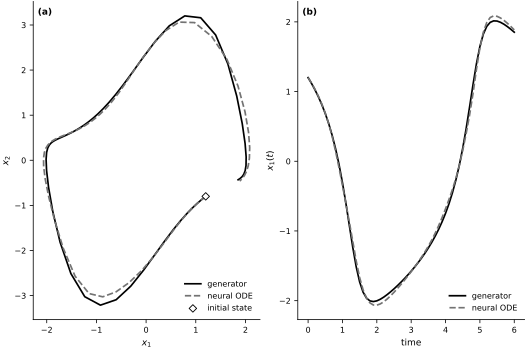

In [10]:
test_y0 = jnp.array([1.2, -0.8], dtype=jnp.float32)
test_true = solve_trajectory(true_term, test_y0, ts)
test_pred = solve_neural_ode(model, test_y0, ts)
test_rel_error = jnp.linalg.norm(test_pred - test_true) / jnp.linalg.norm(test_true)
print(f"Relative error on a new initial condition: {float(test_rel_error):.4f}")

fig, axes = new_figure("full_standard", ncols=2)
axes[0].plot(
    test_true[:, 0],
    test_true[:, 1],
    color="black",
    linewidth=1.7,
    label="generator",
)
axes[0].plot(
    test_pred[:, 0],
    test_pred[:, 1],
    color="0.45",
    linestyle="--",
    linewidth=1.7,
    label="neural ODE",
)
axes[0].scatter(
    [test_y0[0]],
    [test_y0[1]],
    marker="D",
    s=28,
    facecolors="white",
    edgecolors="black",
    linewidths=0.9,
    zorder=10,
    label="initial state",
)
axes[0].set(xlabel=r"$x_1$", ylabel=r"$x_2$")
axes[0].legend(loc="best")

axes[1].plot(
    ts,
    test_true[:, 0],
    color="black",
    linewidth=1.7,
    label="generator",
)
axes[1].plot(
    ts,
    test_pred[:, 0],
    color="0.45",
    linestyle="--",
    linewidth=1.7,
    label="neural ODE",
)
axes[1].set(xlabel="time", ylabel=r"$x_1(t)$")
axes[1].legend(loc="best")
label_panels(axes)
finalize_axes(axes)
plt.show()

## Interpretation and limitations

Neural ODEs replace the hand-designed SINDy library with a flexible parameterization of the vector field. Multiple trajectories constrain that field on a larger visited region, while the held-out result tests one initial condition not used for fitting. The final-loss-to-noise-benchmark ratio compares the residual size with the realized perturbation scale; it does not decompose noise, optimization error, and approximation error, and the benchmark is not a lower bound. The gap between the visited-state and rectangle-wide field errors shows why trajectory fit does not establish global recovery. Global recovery is also impossible for this bounded network representation of the unbounded Van der Pol field. One held-out result likewise does not establish accuracy outside the sampled region or identifiability. All reported errors describe one fixed noise realization and one model initialization, not typical performance across seeds. The fitted network is less directly interpretable than a sparse equation expressed in named candidate terms {cite:p}`brunton2016discovering`.


## Exercises

Restart the kernel and run the notebook from the beginning for each configuration so that the data seed and model initialization remain controlled.

1. Train first on the initial state $(-1.5,0)$ alone and then on the first two listed initial states. Across three initialization seeds, compare the clean training-trajectory error with the visited-state and rectangle-wide vector-field errors.
2. Introduce separate validation and test initial conditions. Compare 1,200, 3,000, and 6,000 updates using validation error, then report the untouched test error once.
3. Increase `noise_std`. Across three data-noise seeds, report the clean training-trajectory and fixed-test-trajectory errors.
4. Change the network width and depth. Use several initialization seeds and the same validation/test protocol to distinguish underfitting from unstable optimization.
5. Replace the Van der Pol oscillator with another two-dimensional system. Rescale time and state, then report the trajectory and vector-field errors on specified training and test regions.
